<a href="https://colab.research.google.com/github/wecwic/beleg-dl-gruppe-1/blob/main/Belegaufgabe_Gruppe_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Belegarbeit Deep Learning für sequentielle Prozessdaten SS2026

# Beleggruppe 1

Gruppen_ID = 1

Namen: (Surname, First Name, Matrikelnummer)

        Manotas Ramos, Rodolfo A., 5054703
        Schnerr, Georg, [Matrikelnummer]
        Schötzau, Jannes, [Matrikelnummer]

In [7]:
## List of Classes for Classification (ignore Acc_Z, Pitting_V2, etc)

selected_axes = ['Acc_X', 'Acc_Y']
selected_classes = ['Gut', 'Mangelschmierung', 'Pitting_V1']

# 0. Bibliotheken importieren

In [8]:
# benötigte Bibliotheken importieren
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix
import optuna

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

%matplotlib inline
import torch

from torch.utils.data import Dataset, DataLoader, Subset

import torch.nn as nn
import torchmetrics

# 1. Daten erfassen - Daten importieren

In [ ]:
# Für Nutzung in Google Colab: Mount Google Drive to access the dataset. Not necessary if running locally; 
# intensity of the task is not sufficient to justify using Google Colab.

# from google.colab import drive
# drive.mount('/content/drive')
# data_path = '/content/drive/MyDrive/DL_Daten/Datensatz.csv'

In [9]:
# Lade Datensatz und Ausgabe Zufallszahl
# Für lokale Nutzung, bitte den Pfad zum Datensatz anpassen

# data_path = 'LINK ZUM DATENSATZ'
data_path = r'C:\dev\beleg-dl-gruppe-1\Datensatz.csv'
df = pd.read_csv(data_path)

df.head(-1)

,Unnamed: 0,index,Acc_X,Acc_Y,Acc_Z,time_ms,rel_time_ms,run_ID,run_status,Status,Velocity,label
0,0,162826,0.040562,0.002472,0.009140,1617806910987,66366,1,-1,Gut,10000,0
1,1,162827,0.040991,0.002469,0.009149,1617806910987,66366,1,-1,Gut,10000,0
2,2,162828,0.041417,0.002465,0.009149,1617806910987,66366,1,-1,Gut,10000,0
3,3,162829,0.041843,0.002461,0.009150,1617806910987,66366,1,-1,Gut,10000,0
4,4,162830,0.024225,-0.001714,-0.000699,1617806910988,66367,1,-1,Gut,10000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4766612,4766612,7243883,0.008971,0.015505,0.015365,1617961507532,707926,813,1,Pitting_V4,10000,5
4766613,4766613,7243884,0.008952,0.015507,0.015378,1617961507532,707926,813,1,Pitting_V4,10000,5
4766614,4766614,7243885,0.025855,0.004554,-0.009693,1617961507533,707927,813,1,Pitting_V4,10000,5
4766615,4766615,7243886,0.025830,0.004561,-0.009681,1617961507533,707927,813,1,Pitting_V4,10000,5


# Daten erkunden

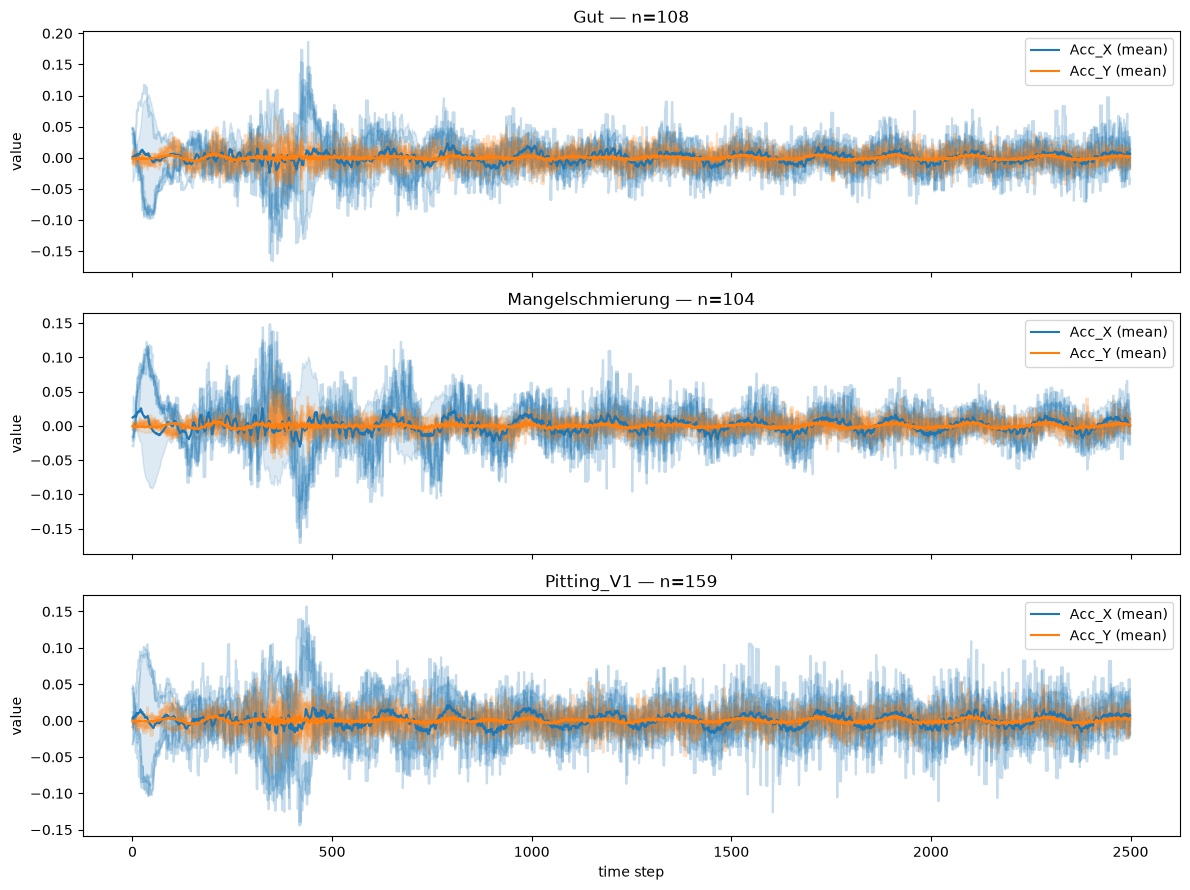

In [46]:
# Visualize selected axes for each selected class: plot a few sample runs (faint) + class mean (bold)
labels = np.argmax(y.reshape(len(y), 3), axis=1)

n_classes = len(selected_classes)
fig, axes = plt.subplots(n_classes, 1, figsize=(12, 3 * n_classes), sharex=True)

rng = np.random.default_rng(0)
t = np.arange(X.shape[1])

for i, cls in enumerate(selected_classes):
    ax = axes[i] if n_classes > 1 else axes
    idxs = np.where(labels == i)[0]
    if len(idxs) == 0:
        ax.set_title(f"{cls} (no samples)")
        continue

    picks = rng.choice(idxs, size=min(5, len(idxs)), replace=False)
    # plot a few individual runs (faint)
    for p in picks:
        ax.plot(t, X[p, :, 0], color='C0', alpha=0.25)
        ax.plot(t, X[p, :, 1], color='C1', alpha=0.25)

    # plot mean ± std
    mean_signal = X[idxs].mean(axis=0)
    std_signal = X[idxs].std(axis=0)
    ax.plot(t, mean_signal[:, 0], color='C0', label='Acc_X (mean)')
    ax.fill_between(t, mean_signal[:, 0] - std_signal[:, 0], mean_signal[:, 0] + std_signal[:, 0],
                    color='C0', alpha=0.15)
    ax.plot(t, mean_signal[:, 1], color='C1', label='Acc_Y (mean)')
    ax.fill_between(t, mean_signal[:, 1] - std_signal[:, 1], mean_signal[:, 1] + std_signal[:, 1],
                    color='C1', alpha=0.15)

    ax.set_title(f"{cls} — n={len(idxs)}")
    ax.set_ylabel("value")
    ax.legend(loc='upper right')

axes[-1].set_xlabel("time step")
plt.tight_layout()
plt.show()

# 2. Daten Vorverarbeitung

In [10]:
####################################################################################################################################################################################################################################################### DIESEN BLOCK NICHT ÄNDERN #########################################################################################
#######################################################################################################################################################################################

def to_categorical(y, num_classes):
    """ 1-hot encodes a tensor """
    return np.eye(num_classes, dtype='uint8')[y]

def data_preprocessing(selected_axes=['Acc_X', 'Acc_Y', 'Acc_Z'], selected_classes=['Gut', 'Mangelschmierung', 'Pitting_V1', 'Pitting_V2', 'Pitting_V3', 'Pitting_V4'], x_len=2500):  # Select which Acc-Data should be included axis: ['Acc_X', 'Acc_Y', 'Acc_Z']
    # file_path = r'd:\Nutzer\boos\_Arbeit\3. IWM-Prozesskette\7. Datensaetze\Boschbett\\PS_total_10000.csv'
    file_path = data_path
    df = pd.read_csv(file_path)
    df = df.drop(df.columns[0:2], axis=1)
    df = df[df['Status'].isin(selected_classes)]

    maxlen = df['run_ID'].value_counts().max()

    if len(selected_classes) < 6:
        label_arr_old = df['label'].values
        label_arr_new = np.zeros(shape=label_arr_old.shape)
        label_arr = np.vstack((label_arr_old, label_arr_new)).T
        i = int(0)
        for idx in np.unique(label_arr_old):
            label_arr[np.where(label_arr[:, 0] == idx), 1] = i
            i += 1
        label_arr = label_arr.astype(int)
        df['label'] = df['label'].map(dict(label_arr))

    n_classes = len(df['label'].value_counts())
    Load = df[['label', 'run_ID']]
    drop_cols = ['label', 'Status', ]
    drop_cols = list(set(drop_cols) & set(df.columns))  # Check if cols are part of df and select only those
    df = df.drop(columns=drop_cols).reset_index(drop=True)
    input_column_names = selected_axes
    x_columns = input_column_names + ['run_ID']
    g = df.groupby('run_ID').cumcount()
    X = (df[x_columns].set_index(['run_ID', g])
         .unstack(fill_value=0)
         .stack().groupby(level=0)
         .apply(lambda x: x.values)
         .to_numpy())
    X = np.array([i for i in X])
    if x_len is not None:
        X = X[:, 0:x_len, :]
        maxlen = x_len
    # del df  <- in case of memory issues
    g = Load.groupby('run_ID').cumcount()

    y = (Load.set_index(['run_ID', g])
         .unstack(fill_value=0)
         .stack().groupby(level=0)
         .apply(lambda x: x.values[0]))
         #.to_numpy().astype("int32"))
    y = np.array(y.tolist(), dtype="int32") # <--- Fix according to Gemini
    
    y = to_categorical(y, n_classes)

    return X, y, maxlen

# 3. Daten für Modell vorbereiten - DataSet Class, Aufteilung in X und y, Normierung

In [11]:
## Define DataSet Class
class DataSet(Dataset):
    # load the dataset
    def __init__(self, X, y):
        self.X = X
        self.y = y

    # number of rows in the dataset
    def __len__(self):
        return len(self.X)

    # get a row at an index
    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]).float(), torch.from_numpy(self.y[idx]).float()

In [12]:
## Data Preprocessing
X, y, maxlen = data_preprocessing(selected_axes=selected_axes,
                                  selected_classes=selected_classes)

## Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    shuffle=True,
                                                    random_state=random.randint(2, 128))

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                  test_size=0.33,
                                                  shuffle=True,
                                                  random_state=random.randint(2, 128))

## Normalize Data
scaler = StandardScaler().fit(np.vstack(X_train))
X_train = scaler.transform(np.vstack(X_train)).reshape(len(X_train), X[0].shape[0], -1)
X_val = scaler.transform(np.vstack(X_val)).reshape(len(X_val), X[0].shape[0], -1)
X_test = scaler.transform(np.vstack(X_test)).reshape(len(X_test), X[0].shape[0], -1)

## Declare Datasets
train_dataset = DataSet(X_train, y_train)
val_dataset = DataSet(X_val, y_val)
test_dataset = DataSet(X_test, y_test)

# Define DataLoaders
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [25]:
# Visualize the shape of the training and validation datasets, for ease of understanding

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (186, 2500, 2)
y_train shape: (186, 1, 3)
X_val shape: (92, 2500, 2)
y_val shape: (92, 1, 3)


# 1D-CNN Basismodel

The input data is sequential; it is also divided into two data streams (Acc_X and Acc_Y). 

A 1D-CNN is a good option since it is suitable for sequential, time-ordered data, and is good at finding patterns in these time sequences, such as value spikes in time-ordered data.

An LSTM could also be used, but a 1D-CNN doesn't have internal memory states, so it might be simpler. Therefore, an initial attempt will be made using a 1D-CNN.

Input layer: 2 inputs (Acc_X and Acc_Y)

Output layer: 3 outputs (Gut, Mangelschimerung, and Pitting_V1)

In [26]:
# 

import torch
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        
        # 1. First Convolutional Block (Looking for basic patterns)
        # in_channels=2 because we have two inputs: Acc_X and Acc_Y

        # 2 features as input, 16 features as output, 5 neighboring values analyzed at once at a time, 
        self.conv1 = nn.Conv1d(in_channels=2, out_channels=16, kernel_size=5, padding=2)

        # Simple ReLU activation function to introduce non-linearity
        self.relu1 = nn.ReLU()

        self.pool1 = nn.MaxPool1d(kernel_size=5) 
        # After pooling, sequence length drops from 2500 to 500, which reduces amount of data to process.
        

        # 2. Second Convolutional Block (Looking for more complex patterns);
        # Same as previous block, but with more input and output channels to capture more complex features.

        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=5) 
        # After pooling again, sequence length drops from 500 to 100
        
        # 3. Fully Connected (Dense) Classifier
        # 32 channels * 100 sequence length = 3200 flattened features
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3200, 64)
        self.relu3 = nn.ReLU()
        
        # Output layer: Exactly 3 neurons for 3 classes (Gut, Mangelschmierung, Pitting_V1)
        self.fc2 = nn.Linear(64, 3) 

    def forward(self, x):
        # Numpy gives us data in shape: (Batch, Sequence, Features) -> (64, 2500, 2)
        # PyTorch Conv1d demands shape: (Batch, Features, Sequence) -> (64, 2, 2500)
        # .permute() flips those last two dimensions instantly so it doesn't crash
        x = x.permute(0, 2, 1) 
        
        # Pass data through the first block
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        # Pass data through the second block
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Flatten and Classify
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x) 
        
        # Notice: No Softmax; CrossEntropyLoss already handles this
        return x

# Initialize the model to make sure it doesn't crash
model = BaselineCNN()
print(model)

BaselineCNN(
  (conv1): Conv1d(2, 16, kernel_size=(5,), stride=(1,), padding=(2,))
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (relu2): ReLU()
  (pool2): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3200, out_features=64, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=64, out_features=3, bias=True)
)


In [27]:
# Loss Function for Multi-Class problems: CrossEntropyLoss
# Good for classification, especially for time series of data with multiple class possibilities.
criterion = nn.CrossEntropyLoss()

# Optimizer (Adam is standard and fast, keeping it simple here)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [28]:
# Creation of DataLoaders for training and validation datasets

# Wrap the numpy arrays in DataSet class provided with Beleg
train_dataset = DataSet(X_train, y_train)
val_dataset = DataSet(X_val, y_val)

# Create the DataLoaders (feeds data in batches of 64)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Training loop
epochs = 10 # Initial number of epochs for training, will increase later if this runs well

print("Starting training...")

for epoch in range(epochs):
    model.train() # Put the model into training mode (allows dropout to work properly)
    running_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # Step A: Clear the old memories (gradients)
        optimizer.zero_grad()
        
        # Step B: PyTorch demands float32 data types, so we convert them
        batch_X = batch_X.float()
        batch_y = batch_y.float()
        
        # Step C: Forward Pass (Let the model guess)
        predictions = model(batch_X)

        # NECESSARY FIX:
        # Convert the one-hot target arrays back into simple class indices (0, 1, or 2)
        # and make sure they are LongTensors (which CrossEntropyLoss demands)
        target_indices = torch.argmax(batch_y.view(-1,3), dim=1).long()
        
        # Step D: Calculate how wrong the guesses were
        # loss = criterion(predictions, batch_y)
        loss = criterion(predictions, target_indices)

        # Step E: Backward Pass (Calculate the fixes)
        loss.backward()
        
        # Step F: Optimizer updates the weights
        optimizer.step()
        
        running_loss += loss.item()
        
    # Print the average loss for this epoch
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} | Training Loss: {avg_loss:.4f}")

print("Initial training successful!")

Starting training...
Epoch 1/10 | Training Loss: 1.1434
Epoch 2/10 | Training Loss: 1.0892
Epoch 3/10 | Training Loss: 1.0566
Epoch 4/10 | Training Loss: 1.0082
Epoch 5/10 | Training Loss: 0.9861
Epoch 6/10 | Training Loss: 0.9284
Epoch 7/10 | Training Loss: 0.8718
Epoch 8/10 | Training Loss: 0.8258
Epoch 9/10 | Training Loss: 0.7431
Epoch 10/10 | Training Loss: 0.6761
Initial training successful!


In [29]:
# Evaluation of the model
# Model in evaluation mode (turns off training-only features like Dropout)
model.eval()

correct_guesses = 0
total_samples = 0

print("Testing the model on validation data...")

# torch.no_grad() tells PyTorch to stop tracking gradients (saves memory and speeds up testing)
with torch.no_grad():
    for batch_X, batch_y in val_loader:
        # 1. Convert types
        batch_X = batch_X.float()
        batch_y = batch_y.float()
        
        # 2. Get the model's raw guesses
        predictions = model(batch_X)
        
        # 3. Convert guesses into class numbers (0, 1, or 2)
        predicted_classes = torch.argmax(predictions, dim=1)
        
        # 4. Convert true answers into class numbers (this is necessary or otherwise the comparison will fail)
        true_classes = torch.argmax(batch_y.view(-1, 3), dim=1).long()
        
        # 5. Count how many were right
        total_samples += true_classes.size(0)
        correct_guesses += (predicted_classes == true_classes).sum().item()

# Calculate the final percentage
val_accuracy = 100 * correct_guesses / total_samples
print(f"Validation Accuracy: {val_accuracy:.2f}%")

if val_accuracy >= 55.0:
    print("55% threshold reached!")
else:
    print("55% threshold not reached; training or parameter tuning necessary")

Testing the model on Validation Data...
Validation Accuracy: 68.48%
55% threshold reached!


In [30]:
# Testing model with test dataset (unseen data)
# Model still in evaluation mode (no Dropout)
model.eval()

correct_guesses = 0
total_samples = 0

print("Testing the model on testing data...")

test_loader = DataLoader(DataSet(X_test, y_test), batch_size=64, shuffle=False)

# torch.no_grad() tells PyTorch to stop tracking gradients (saves memory and speeds up testing)
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        # 1. Convert types
        batch_X = batch_X.float()
        batch_y = batch_y.float()
        
        # 2. Get the model's raw guesses
        predictions = model(batch_X)
        
        # 3. Convert guesses into class numbers (0, 1, or 2)
        predicted_classes = torch.argmax(predictions, dim=1)
        
        # 4. Convert true answers into class numbers (this is necessary or otherwise the comparison will fail)
        true_classes = torch.argmax(batch_y.view(-1, 3), dim=1).long()
        
        # 5. Count how many were right
        total_samples += true_classes.size(0)
        correct_guesses += (predicted_classes == true_classes).sum().item()

# Calculate the final percentage
val_accuracy = 100 * correct_guesses / total_samples
print(f"Validation Accuracy: {val_accuracy:.2f}%")

if val_accuracy >= 55.0:
    print("55% threshold reached!")
else:
    print("55% threshold not reached; training or parameter tuning necessary!")

Testing the model on testing data...
Validation Accuracy: 73.12%
55% threshold reached!


# Confusion matrix: Visualisierung der aktuellen Modelleistung pro "Class"

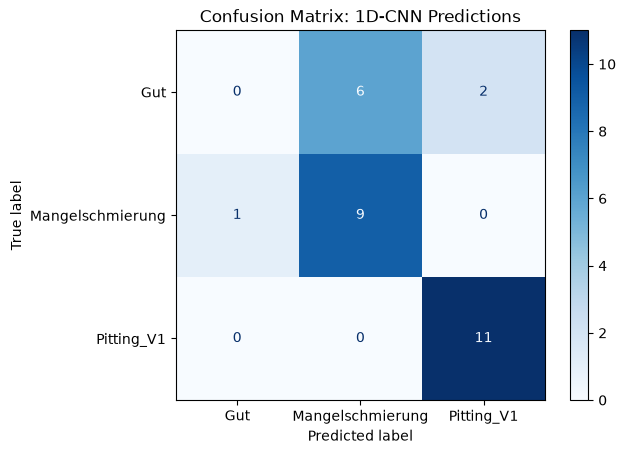

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

# Draw the Confusion Matrix to get an idea of how well the model is performing on each class
cm = confusion_matrix(true_classes.cpu(), predicted_classes.cpu())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=selected_classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: 1D-CNN Predictions")
plt.show()

# Hyperparameter-Optimierung mit Optuna

In [38]:
import optuna

print("Initiating Optuna Hyperparameter Search...")

def objective(trial):
    # Let Optuna pick the Learning Rate and the size of the Linear Layer
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    fc_size = trial.suggest_categorical("fc_size", [32, 64, 128]) # initial guesses for fully connected layer size
    
    # Building dynamic model
    class TunedCNN(nn.Module):
        def __init__(self, fc_size):
            super(TunedCNN, self).__init__()
            self.conv1 = nn.Conv1d(2, 16, kernel_size=5, padding=2)
            self.relu1 = nn.ReLU()
            self.pool1 = nn.MaxPool1d(5)
            self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
            self.relu2 = nn.ReLU()
            self.pool2 = nn.MaxPool1d(5)
            self.flatten = nn.Flatten()
            
            # The size here changes based on Optuna's current guess
            self.fc1 = nn.Linear(3200, fc_size)
            self.relu3 = nn.ReLU()
            self.fc2 = nn.Linear(fc_size, 3)

        def forward(self, x):
            x = x.permute(0, 2, 1)
            x = self.pool1(self.relu1(self.conv1(x)))
            x = self.pool2(self.relu2(self.conv2(x)))
            x = self.flatten(x)
            x = self.fc2(self.relu3(self.fc1(x)))
            return x

    model = TunedCNN(fc_size)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Train for more epochs than in previous testing (20 instead of 10)
    epochs = 20
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X.float())
            target_indices = torch.argmax(batch_y.view(-1, 3), dim=1).long()
            loss = criterion(predictions, target_indices)
            loss.backward()
            optimizer.step()
            
    # Evaluation of this specific model
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X.float())
            predicted_classes = torch.argmax(predictions, dim=1)
            true_classes = torch.argmax(batch_y.view(-1, 3), dim=1).long()
            total += true_classes.size(0)
            correct += (predicted_classes == true_classes).sum().item()
            
    # Return the accuracy so Optuna knows how well it did
    return correct / total

# Create the study and run 15 trials
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("\n--- OPTUNA SEARCH COMPLETE ---")
print(f"Best Validation Accuracy: {study.best_value * 100:.2f}%")
print("Best Hyperparameters:", study.best_params)

[I 2026-07-28 16:58:14,416] A new study created in memory with name: no-name-de7a801a-827d-4cc8-bf05-a5ba2cc546de


Initiating Optuna Hyperparameter Search...


[I 2026-07-28 16:58:15,464] Trial 0 finished with value: 0.8478260869565217 and parameters: {'lr': 0.0012970483975968594, 'fc_size': 128}. Best is trial 0 with value: 0.8478260869565217.
[I 2026-07-28 16:58:16,426] Trial 1 finished with value: 0.5652173913043478 and parameters: {'lr': 0.00020109073339127207, 'fc_size': 32}. Best is trial 0 with value: 0.8478260869565217.
[I 2026-07-28 16:58:17,441] Trial 2 finished with value: 0.8043478260869565 and parameters: {'lr': 0.00031609277288364133, 'fc_size': 128}. Best is trial 0 with value: 0.8478260869565217.
[I 2026-07-28 16:58:18,441] Trial 3 finished with value: 0.7717391304347826 and parameters: {'lr': 0.0001855173900383636, 'fc_size': 128}. Best is trial 0 with value: 0.8478260869565217.
[I 2026-07-28 16:58:19,453] Trial 4 finished with value: 0.7608695652173914 and parameters: {'lr': 0.00016218533222751275, 'fc_size': 128}. Best is trial 0 with value: 0.8478260869565217.
[I 2026-07-28 16:58:20,421] Trial 5 finished with value: 0.8695


--- OPTUNA SEARCH COMPLETE ---
Best Validation Accuracy: 93.48%
Best Hyperparameters: {'lr': 0.0013260144176029595, 'fc_size': 128}


Building the Champion Model...
Using Auto-Extracted Parameters - LR: 0.00133, FC_Size: 128
Training the Champion Model...
Generating Confusion Matrix...


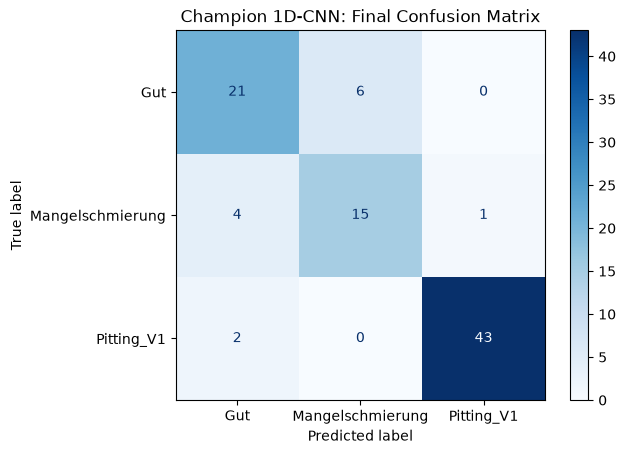

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Building the Champion Model...")

# Building model with the best hyperparameters found by Optuna

# Manual parameter input, if desired:
# best_lr = 0.0017884144414630936
# best_fc_size = 32

# Automatic parameter extraction from Optuna:
best_lr = study.best_params['lr']
best_fc_size = study.best_params['fc_size']

print(f"Using Auto-Extracted Parameters - LR: {best_lr:.5f}, FC_Size: {best_fc_size}")

class ChampionCNN(nn.Module):
    def __init__(self):
        super(ChampionCNN, self).__init__()
        self.conv1 = nn.Conv1d(2, 16, kernel_size=5, padding=2)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(5)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(5)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3200, best_fc_size) # <--- Optuna's Choice
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(best_fc_size, 3)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.fc2(self.relu3(self.fc1(x)))
        return x

# Assmbling with criterion, optimizer
champion_model = ChampionCNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(champion_model.parameters(), lr=best_lr) # <--- Optuna's Choice

# Training model using optimal parameters, 30 epochs
print("Training the Champion Model...")
epochs = 30
for epoch in range(epochs):
    champion_model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = champion_model(batch_X.float())
        target_indices = torch.argmax(batch_y.view(-1, 3), dim=1).long()
        loss = criterion(predictions, target_indices)
        loss.backward()
        optimizer.step()

# Confusion matrix for optimal model
print("Generating Confusion Matrix...")
champion_model.eval()
all_preds = []
all_trues = []

with torch.no_grad():
    for batch_X, batch_y in val_loader: # Testing against the validation data
        predictions = champion_model(batch_X.float())
        
        predicted_classes = torch.argmax(predictions, dim=1)
        true_classes = torch.argmax(batch_y.view(-1, 3), dim=1).long()
        
        # Save the answers to a list so sklearn can draw the matrix
        all_preds.extend(predicted_classes.cpu().numpy())
        all_trues.extend(true_classes.cpu().numpy())

# Confusion matrix display
cm = confusion_matrix(all_trues, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=selected_classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Champion 1D-CNN: Final Confusion Matrix")
plt.show()

# FINAL TEST (of optimal model)

In [45]:
# Final test of the "Champion Model" on unseen test data

# 1. Create the Test DataLoader
test_dataset = DataSet(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Run the Evaluation
print("Running Final Exam on Test Data...")
champion_model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        predictions = champion_model(batch_X.float())
        
        predicted_classes = torch.argmax(predictions, dim=1)
        true_classes = torch.argmax(batch_y.view(-1, 3), dim=1).long()
        
        test_total += true_classes.size(0)
        test_correct += (predicted_classes == true_classes).sum().item()

# 3. Calculate final test Accuracy
final_test_accuracy = 100 * test_correct / test_total

print(f"FINAL TEST ACCURACY: {final_test_accuracy:.2f}%")

if final_test_accuracy >= 55.0:
    print("The model has officially met the Beleg requirements *</:-D")

# Saving model weights for future use bc why not (would be a shame to lose this model)

# Definition of path in .pt format (PyTorch standard)
end_file_path = 'Champion_1D_CNN.pt'

# Saving model to previous path
torch.save(champion_model.state_dict(), end_file_path)

print(f"Model weights successfully saved to: {end_file_path}")

Running Final Exam on Test Data...
FINAL TEST ACCURACY: 83.87%
The model has officially met the Beleg requirements *</:-D
Model weights successfully saved to: Champion_1D_CNN.pt
